In [2]:
############################ Data Analysis & Calculation ############################

import numpy as np 
import pandas as pd 

############################ Ignore Warning  ############################
import warnings
warnings.filterwarnings("ignore")

############################ Data visualization ############################

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import pickle

# 1. Data Importing

In [3]:
import pandas as pd
df = pd.read_csv (r"C:\Users\ASUS\Downloads\pune_pg_dataset_1000.csv")
df.head()

,pg_name,location,rent,sharing_type,size_sqft,wifi,ac,food,parking,laundry,power_backup,security,housekeeping,attached_bathroom,geyser,gender,preferred_tenant,rating
0,CoHo Hadapsar,Hadapsar,11458,Single,449,0,0,1,0,0,0,1,0,0,0,Any,Working,3.6
1,LivStation Pimpri,Pimpri,12047,Double,398,1,1,1,1,0,0,1,1,1,0,Any,Student,4.1
2,YourSpace Hinjewadi,Hinjewadi,9773,Triple,438,1,1,0,0,0,0,0,0,0,0,Female,Working,4.1
3,SmartLiving Magarpatta,Magarpatta,17034,Single,430,1,1,1,0,1,0,1,0,1,0,Female,Working,4.6
4,YourSpace Viman Nagar,Viman Nagar,16957,Double,619,1,1,1,0,0,1,1,1,1,1,Any,Working,4.0


#### 2.1. Data Type and conversion

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pg_name            1000 non-null   object 
 1   location           1000 non-null   object 
 2   rent               1000 non-null   int64  
 3   sharing_type       1000 non-null   object 
 4   size_sqft          1000 non-null   int64  
 5   wifi               1000 non-null   int64  
 6   ac                 1000 non-null   int64  
 7   food               1000 non-null   int64  
 8   parking            1000 non-null   int64  
 9   laundry            1000 non-null   int64  
 10  power_backup       1000 non-null   int64  
 11  security           1000 non-null   int64  
 12  housekeeping       1000 non-null   int64  
 13  attached_bathroom  1000 non-null   int64  
 14  geyser             1000 non-null   int64  
 15  gender             1000 non-null   object 
 16  preferred_tenant   1000 n

In [5]:
df.isnull().sum()

pg_name              0
location             0
rent                 0
sharing_type         0
size_sqft            0
wifi                 0
ac                   0
food                 0
parking              0
laundry              0
power_backup         0
security             0
housekeeping         0
attached_bathroom    0
geyser               0
gender               0
preferred_tenant     0
rating               0
dtype: int64

<Axes: >

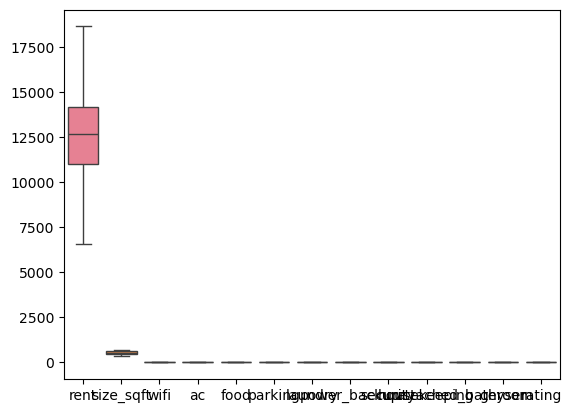

In [6]:
sns.boxplot(data= df)

DATA VISUALIZATION

<Axes: xlabel='location', ylabel='rent'>

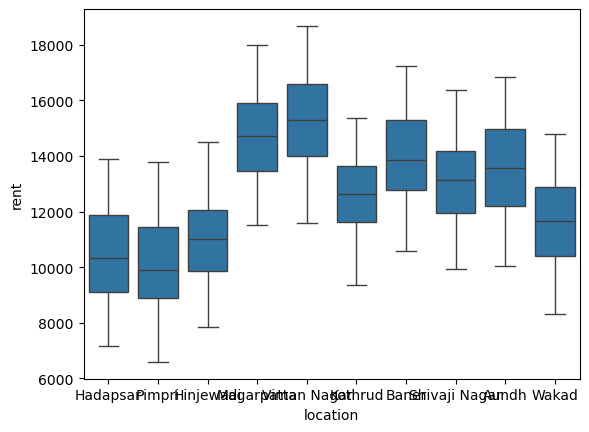

In [7]:
sns.boxplot(x=df['location'], y=df['rent'])

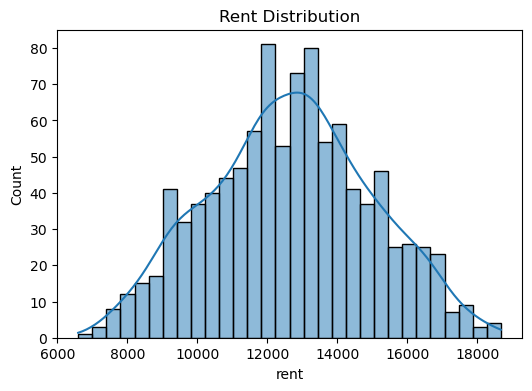

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=30, kde=True)
plt.title("Rent Distribution")
plt.show()

In [9]:
print(df.columns)

Index(['pg_name', 'location', 'rent', 'sharing_type', 'size_sqft', 'wifi',
       'ac', 'food', 'parking', 'laundry', 'power_backup', 'security',
       'housekeeping', 'attached_bathroom', 'geyser', 'gender',
       'preferred_tenant', 'rating'],
      dtype='object')


<Axes: xlabel='location', ylabel='rent'>

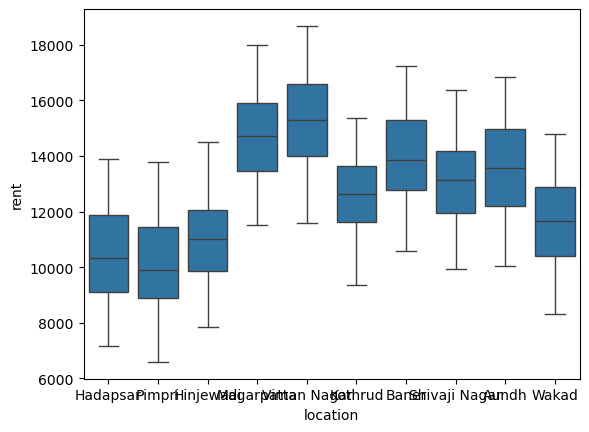

In [10]:
sns.boxplot(x=df['location'], y=df['rent'])

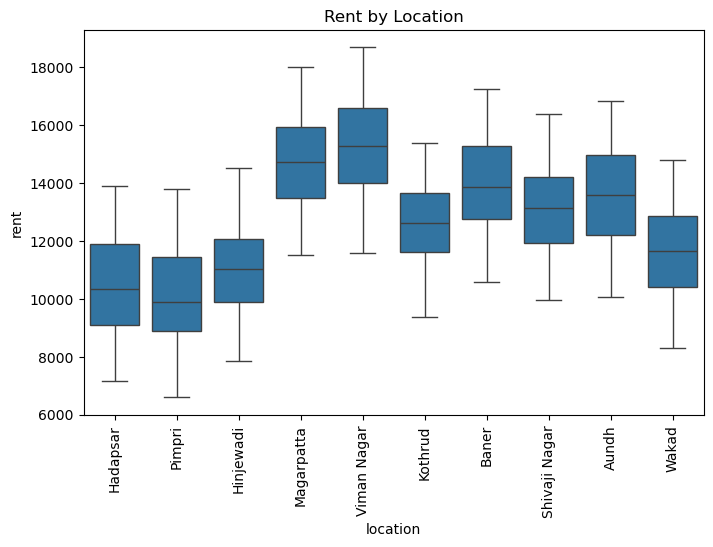

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['location'], y=df['rent'])
plt.xticks(rotation=90)
plt.title("Rent by Location")
plt.show()


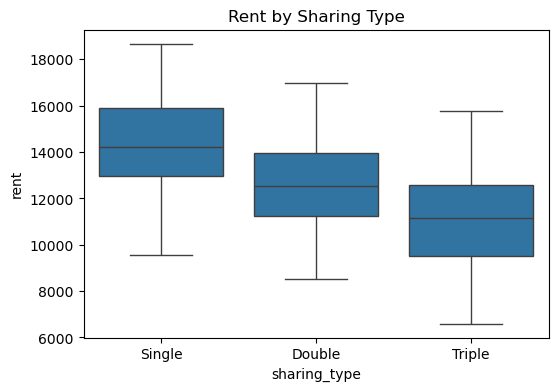

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['sharing_type'], y=df['rent'])
plt.title("Rent by Sharing Type")
plt.show()

# Model

In [13]:
# Convert categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

print(df.head())

    rent  size_sqft  wifi  ac  food  parking  laundry  power_backup  security  \
0  11458        449     0   0     1        0        0             0         1   
1  12047        398     1   1     1        1        0             0         1   
2   9773        438     1   1     0        0        0             0         0   
3  17034        430     1   1     1        0        1             0         1   
4  16957        619     1   1     1        0        0             1         1   

   housekeeping  ...  location_Magarpatta  location_Pimpri  \
0             0  ...                False            False   
1             1  ...                False             True   
2             0  ...                False            False   
3             0  ...                 True            False   
4             1  ...                False            False   

   location_Shivaji Nagar  location_Viman Nagar  location_Wakad  \
0                   False                 False           False   
1     

In [14]:
X = df.drop("rent", axis=1)   # Features
y = df["rent"]                # Target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
import json

with open("columns.json", "w") as f:
    json.dump(list(X.columns), f)

print("✅ columns.json created")

✅ columns.json created


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)   # 🔥 THIS LINE IS MUST

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
y_pred = model.predict(X_test)

In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.9570272824390288
MAE: 399.21925000000005


In [20]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("pune_pg_dataset_1000.csv")

# Drop unnecessary column
df.drop("pg_name", axis=1, inplace=True)

# Convert Yes/No to 1/0 (if needed)
binary_cols = ["wifi","ac","food","parking","laundry",
               "power_backup","security","housekeeping",
               "attached_bathroom","geyser"]

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map({"Yes":1,"No":0})

# CREATE ENCODERS (VERY IMPORTANT)
le_location = LabelEncoder()
le_sharing = LabelEncoder()
le_gender = LabelEncoder()
le_tenant = LabelEncoder()

df["location"] = le_location.fit_transform(df["location"])
df["sharing_type"] = le_sharing.fit_transform(df["sharing_type"])
df["gender"] = le_gender.fit_transform(df["gender"])
df["preferred_tenant"] = le_tenant.fit_transform(df["preferred_tenant"])

# Split data
X = df.drop("rent", axis=1)
y = df["rent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

# SAVE FILES (THIS CREATES .pkl FILES)
pickle.dump(model, open("pg_rent_model.pkl", "wb"))
pickle.dump(le_location, open("le_location.pkl", "wb"))
pickle.dump(le_sharing, open("le_sharing.pkl", "wb"))

print("✅ All files saved successfully!")

✅ All files saved successfully!


In [21]:
import pickle

# Save model
pickle.dump(model, open("pg_rent_model.pkl", "wb"))

# Save encoders
pickle.dump(le_location, open("le_location.pkl", "wb"))
pickle.dump(le_sharing, open("le_sharing.pkl", "wb"))
pickle.dump(le_gender, open("le_gender.pkl", "wb"))
pickle.dump(le_tenant, open("le_tenant.pkl", "wb"))

In [22]:
sample = X.iloc[0:1]   # sample input
prediction = model.predict(sample)

print("Predicted Rent:", prediction[0])

Predicted Rent: 11735.265


FEATURE IMPORTANCE

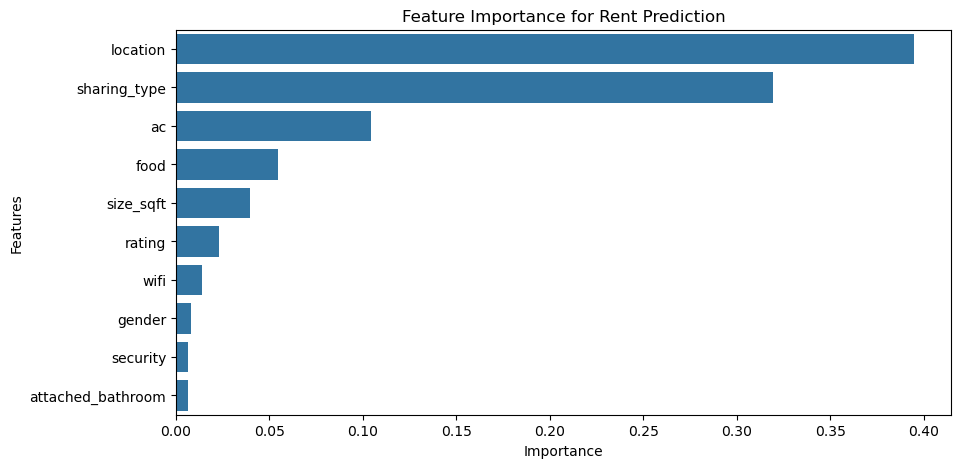

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
imp = pd.Series(data=model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,5))
plt.title("Feature Importance for Rent Prediction")

sns.barplot(
    y=imp.sort_values(ascending=False).head(10).index,
    x=imp.sort_values(ascending=False).head(10).values
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

BUSINESS SUBMISSION

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("TRAIN PERFORMANCE")
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTEST PERFORMANCE")
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

TRAIN PERFORMANCE
R2: 0.988216595147502
MAE: 192.50310624999997

TEST PERFORMANCE
R2: 0.9114443976383433
MAE: 548.8148249999999


The model predicts PG rent with high accuracy using Random Forest.
It helps users estimate fair pricing based on:
- Location
- Sharing type
- Amenities

This can be used by:
- Students searching PGs
- PG owners setting prices
- Real estate platforms

LIVE DATA PREDICTION

In [25]:
# Take some test data
live_data = X_test.iloc[0:5, :]

# Predict rent
live_data['Predicted_Rent'] = model.predict(live_data)

live_data


,location,sharing_type,size_sqft,wifi,ac,food,parking,laundry,power_backup,security,housekeeping,attached_bathroom,geyser,gender,preferred_tenant,rating,Predicted_Rent
879,1,1,624,1,0,0,1,0,0,0,0,1,0,1,1,3.8,14457.935
423,6,1,628,0,1,1,0,0,1,1,1,1,1,0,1,4.5,14247.170
891,7,0,523,0,1,0,1,1,1,1,1,0,1,0,1,4.4,13671.020
954,6,1,460,1,1,0,1,0,1,1,1,1,1,1,1,4.3,13106.375
264,1,0,375,0,0,1,1,1,0,0,0,1,1,2,1,4.0,13601.590


The model was tested on live sample data to evaluate real-world performance.

Each row represents a PG property with features such as:
- Size (sqft)
- WiFi availability
- AC facility
- Food service
- Parking
- Laundry
- Power backup
- Security
- Housekeeping

The model successfully predicted rent values for all 5 entries.

Observations:
- Properties with more amenities (WiFi, AC, food, parking) tend to have higher predicted rent.
- Larger room size (sqft) also contributes to increased rent.
- Basic facilities (security, power backup) show moderate impact on pricing.
- Listings with fewer amenities are predicted with lower rent.

Conclusion:
The model is able to generalize well and provide realistic rent estimates based on property features, making it suitable for real-world deployment.

In [26]:
with open(r"D:\rent_model.pkl", "wb") as file:
    pickle.dump(model, file)